# 풍력발전량 2-Stage 잔차보정 — 2024 단일 외부 검증

1단계 LightGBM+CatBoost가 발전량을 예측하고, 2단계 LightGBM+CatBoost가 1단계의 잔차를 예측합니다.

- 외부 검증 데이터는 2024년 전체 하나만 사용합니다.
- 2022~2023년 내부 4-fold는 검증 데이터가 아니라 누수 없는 잔차 학습값을 만드는 과정입니다.
- 설정 확정 후 2022~2024년 전체 OOF 잔차로 2단계를 다시 학습하고 2025년을 예측합니다.
- 0·저출력·고풍속·설비용량·감발 보정은 사용하지 않습니다.


## 1. 실행 환경과 모델 설정

시드는 42로 고정합니다. 최대 트리 수를 넉넉히 두고 내부 fold의 early stopping으로 실제 사용할 트리 수를 찾습니다.


In [1]:
from __future__ import annotations

import json
import pickle
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from matplotlib import font_manager, rcParams
from sklearn.model_selection import KFold

ROOT = Path(r"C:\jupyter project")
DATA_DIR = ROOT / "wind_data"
PREPROCESSED_DIR = DATA_DIR / "preprocessed"
OUTPUT_DIR = ROOT / "wind_2stage_residual_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIME_COL = "forecast_kst_dtm"
VALID_START = pd.Timestamp("2024-01-01 00:00:00")
VALID_END = pd.Timestamp("2024-12-31 23:59:59")
RANDOM_SEED = 42
N_SPLITS = 4
N_JOBS = -1

GROUPS = {
    1: {"target": "kpx_group_1", "capacity": 21600.0},
    2: {"target": "kpx_group_2", "capacity": 21600.0},
    3: {"target": "kpx_group_3", "capacity": 21000.0},
}

BASE_LGB_MAX_TREES = 5000
BASE_CAT_MAX_TREES = 4500
RES_LGB_MAX_TREES = 2500
RES_CAT_MAX_TREES = 2200
BASE_PATIENCE = 250
RES_PATIENCE = 200

BASE_LGB_PARAMS = {
    "objective": "regression_l1", "learning_rate": 0.02,
    "num_leaves": 63, "min_child_samples": 35,
    "subsample": 0.85, "subsample_freq": 1, "colsample_bytree": 0.85,
    "reg_alpha": 0.15, "reg_lambda": 1.50,
    "n_jobs": N_JOBS, "verbosity": -1,
}
BASE_CAT_PARAMS = {
    "loss_function": "MAE", "eval_metric": "MAE", "learning_rate": 0.025,
    "depth": 9, "l2_leaf_reg": 7.0, "random_strength": 0.30,
    "bootstrap_type": "Bernoulli", "subsample": 0.85, "rsm": 0.90,
    "allow_writing_files": False, "verbose": False, "thread_count": -1,
}
RES_LGB_PARAMS = {
    "objective": "regression_l1", "learning_rate": 0.02,
    "num_leaves": 15, "max_depth": 5, "min_child_samples": 100,
    "subsample": 0.80, "subsample_freq": 1, "colsample_bytree": 0.75,
    "reg_alpha": 0.50, "reg_lambda": 4.00,
    "n_jobs": N_JOBS, "verbosity": -1,
}
RES_CAT_PARAMS = {
    "loss_function": "MAE", "eval_metric": "MAE", "learning_rate": 0.025,
    "depth": 6, "l2_leaf_reg": 10.0, "random_strength": 0.50,
    "bootstrap_type": "Bernoulli", "subsample": 0.80, "rsm": 0.80,
    "allow_writing_files": False, "verbose": False, "thread_count": -1,
}

BASE_WEIGHT_CANDIDATES = np.round(np.linspace(0.0, 1.0, 21), 2)
RESIDUAL_WEIGHT_CANDIDATES = np.round(np.linspace(0.0, 1.0, 21), 2)
BETA_CANDIDATES = np.round(np.linspace(0.0, 1.0, 21), 2)

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in ["Malgun Gothic", "맑은 고딕", "NanumGothic"] if f in installed_fonts), None)
if selected_font:
    rcParams["font.family"] = selected_font
else:
    warnings.warn("한글 폰트를 찾지 못해 그래프 글자가 깨질 수 있습니다.")
rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=selected_font)

print("seed:", RANDOM_SEED)
print("외부 검증: 2024년 전체")
print("내부 OOF fold:", N_SPLITS)
print("결과 폴더:", OUTPUT_DIR)


seed: 42
외부 검증: 2024년 전체
내부 OOF fold: 4
결과 폴더: C:\jupyter project\wind_2stage_residual_output


## 2. 데이터와 DACON 공식 평가 함수

실제 발전량이 설비용량의 10% 이상인 시간만 평가합니다. NMAE와 FICR을 계산한 뒤
`Score = 0.5 × (1-NMAE) + 0.5 × FICR`을 사용합니다. 모델 학습에는 전처리된 모든 행을
같은 가중치로 사용합니다.


In [2]:
def read_group(group_id):
    train_path = PREPROCESSED_DIR / f"train_group{group_id}_preprocessed.csv"
    test_path = PREPROCESSED_DIR / f"test_group{group_id}_preprocessed.csv"
    if not train_path.exists() or not test_path.exists():
        raise FileNotFoundError("전처리 CSV가 없습니다. '전처리 최종.py'를 먼저 실행하세요.")
    train = pd.read_csv(
        train_path, encoding="utf-8-sig", parse_dates=[TIME_COL]
    ).sort_values(TIME_COL).reset_index(drop=True)
    test = pd.read_csv(
        test_path, encoding="utf-8-sig", parse_dates=[TIME_COL]
    ).sort_values(TIME_COL).reset_index(drop=True)
    return train, test


def feature_frames(train, test, target):
    feature_cols = [c for c in train.columns if c not in {TIME_COL, target}]
    test_cols = [c for c in test.columns if c != TIME_COL]
    if feature_cols != test_cols:
        raise ValueError("Train/Test 입력변수 이름 또는 순서가 다릅니다.")
    x_all = train[feature_cols].copy()
    x_test = test[feature_cols].copy()
    for col in feature_cols:
        if pd.api.types.is_bool_dtype(x_all[col]):
            x_all[col] = x_all[col].astype("int8")
            x_test[col] = x_test[col].astype("int8")
        elif not pd.api.types.is_numeric_dtype(x_all[col]):
            x_all[col] = pd.to_numeric(x_all[col], errors="raise")
            x_test[col] = pd.to_numeric(x_test[col], errors="raise")
    if x_all.isna().any().any() or x_test.isna().any().any():
        raise ValueError("모델 입력변수에 결측치가 있습니다.")
    return x_all, x_test, feature_cols


def official_group_metrics(y_true_ratio, pred_ratio):
    actual = np.asarray(y_true_ratio, dtype=float)
    forecast = np.asarray(pred_ratio, dtype=float)
    valid = actual >= 0.10
    if not valid.any():
        raise ValueError("공식 평가 대상 행이 없습니다.")
    actual = actual[valid]
    forecast = forecast[valid]
    error_rate = np.abs(forecast - actual)
    nmae = float(error_rate.mean())
    unit_price = np.select(
        [error_rate <= 0.06, error_rate <= 0.08],
        [4.0, 3.0],
        default=0.0,
    )
    ficr = float(np.sum(actual * unit_price) / np.sum(actual * 4.0))
    one_minus_nmae = 1.0 - nmae
    score = 0.5 * one_minus_nmae + 0.5 * ficr
    return {
        "Score": float(score),
        "one_minus_NMAE": float(one_minus_nmae),
        "NMAE": nmae,
        "FICR": ficr,
        "eligible_hours": int(valid.sum()),
    }


def better_metrics(candidate, best):
    if candidate["Score"] > best["Score"] + 1e-12:
        return True
    return (
        abs(candidate["Score"] - best["Score"]) <= 1e-12
        and candidate["NMAE"] < best["NMAE"] - 1e-12
    )


# 공식 함수의 10% 제외와 정산단가 계산을 간단히 자체 검사합니다.
_check = official_group_metrics(
    np.array([0.05, 0.20, 0.50]),
    np.array([1.00, 0.20, 0.57]),
)
assert _check["eligible_hours"] == 2
assert np.isclose(_check["FICR"], (0.20 * 4 + 0.50 * 3) / ((0.20 + 0.50) * 4))
print("공식 평가 함수 자체 검사 통과")


공식 평가 함수 자체 검사 통과


## 3. 기본모델·잔차모델 함수

내부 KFold에서 early stopping을 적용해 fold별 최적 트리 수를 찾고 중앙값을 사용합니다. OOF 예측은 각 행을 직접 학습하지 않은 모델에서만 생성됩니다.


In [3]:
def lgb_eligible_nmae(y_true, y_pred):
    """대회처럼 실제 발전량 10% 이상 행만 사용하는 early stopping 지표입니다."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true >= 0.10
    value = np.mean(np.abs(y_pred[mask] - y_true[mask])) if mask.any() else np.mean(np.abs(y_pred - y_true))
    return "eligible_nmae", float(value), False


def fit_base_validation(x_train, y_train, x_valid, y_valid):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=BASE_LGB_MAX_TREES, random_state=RANDOM_SEED,
        **BASE_LGB_PARAMS,
    )
    lgb_model.fit(
        x_train, y_train, eval_set=[(x_valid, y_valid)],
        eval_metric=lgb_eligible_nmae,
        callbacks=[lgb.early_stopping(BASE_PATIENCE, first_metric_only=True, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_iteration = int(lgb_model.best_iteration_ or BASE_LGB_MAX_TREES)

    cat_model = CatBoostRegressor(
        iterations=BASE_CAT_MAX_TREES, random_seed=RANDOM_SEED,
        **BASE_CAT_PARAMS,
    )
    cat_model.fit(
        x_train, y_train, eval_set=(x_valid, y_valid),
        early_stopping_rounds=BASE_PATIENCE, use_best_model=True,
    )
    cat_iteration = max(50, int(cat_model.get_best_iteration()) + 1)
    return {
        "lgb_pred": lgb_model.predict(x_valid, num_iteration=lgb_iteration),
        "cat_pred": cat_model.predict(x_valid),
        "lgb_iteration": lgb_iteration,
        "cat_iteration": cat_iteration,
    }


def fit_residual_validation(x_train, y_train, x_valid, y_valid):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=RES_LGB_MAX_TREES, random_state=RANDOM_SEED,
        **RES_LGB_PARAMS,
    )
    lgb_model.fit(
        x_train, y_train, eval_set=[(x_valid, y_valid)], eval_metric="mae",
        callbacks=[lgb.early_stopping(RES_PATIENCE, verbose=False), lgb.log_evaluation(0)],
    )
    lgb_iteration = int(lgb_model.best_iteration_ or RES_LGB_MAX_TREES)
    cat_model = CatBoostRegressor(
        iterations=RES_CAT_MAX_TREES, random_seed=RANDOM_SEED,
        **RES_CAT_PARAMS,
    )
    cat_model.fit(
        x_train, y_train, eval_set=(x_valid, y_valid),
        early_stopping_rounds=RES_PATIENCE, use_best_model=True,
    )
    cat_iteration = max(30, int(cat_model.get_best_iteration()) + 1)
    return {
        "lgb_pred": lgb_model.predict(x_valid, num_iteration=lgb_iteration),
        "cat_pred": cat_model.predict(x_valid),
        "lgb_iteration": lgb_iteration,
        "cat_iteration": cat_iteration,
    }


def fit_base_fixed(x_train, y_train, lgb_iteration, cat_iteration):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=int(lgb_iteration), random_state=RANDOM_SEED,
        **BASE_LGB_PARAMS,
    ).fit(x_train, y_train)
    cat_model = CatBoostRegressor(
        iterations=int(cat_iteration), random_seed=RANDOM_SEED,
        **BASE_CAT_PARAMS,
    ).fit(x_train, y_train)
    return lgb_model, cat_model


def fit_residual_fixed(x_train, y_train, lgb_iteration, cat_iteration):
    lgb_model = lgb.LGBMRegressor(
        n_estimators=int(lgb_iteration), random_state=RANDOM_SEED,
        **RES_LGB_PARAMS,
    ).fit(x_train, y_train)
    cat_model = CatBoostRegressor(
        iterations=int(cat_iteration), random_seed=RANDOM_SEED,
        **RES_CAT_PARAMS,
    ).fit(x_train, y_train)
    return lgb_model, cat_model


def make_stage2_features(x_original, lgb_pred, cat_pred, base_pred):
    result = x_original.reset_index(drop=True).copy()
    lgb_pred = np.asarray(lgb_pred, dtype=float)
    cat_pred = np.asarray(cat_pred, dtype=float)
    result["stage1_lgb_pred"] = lgb_pred
    result["stage1_cat_pred"] = cat_pred
    result["stage1_pred_mean"] = (lgb_pred + cat_pred) / 2.0
    result["stage1_pred_diff"] = lgb_pred - cat_pred
    result["stage1_base_blend"] = np.asarray(base_pred, dtype=float)
    return result


def choose_base_weight(y_true, lgb_pred, cat_pred):
    best = None
    for weight in BASE_WEIGHT_CANDIDATES:
        pred = np.maximum(0.0, weight * lgb_pred + (1.0 - weight) * cat_pred)
        metrics = official_group_metrics(y_true, pred)
        candidate = {"weight": float(weight), "pred": pred, "metrics": metrics}
        if best is None or better_metrics(metrics, best["metrics"]):
            best = candidate
    return best


def choose_residual_blend(y_true, base_pred, residual_lgb, residual_cat):
    best = {
        "residual_lgb_weight": 0.5, "beta": 0.0,
        "pred": np.maximum(0.0, base_pred),
    }
    best["metrics"] = official_group_metrics(y_true, best["pred"])
    for weight in RESIDUAL_WEIGHT_CANDIDATES:
        residual = weight * residual_lgb + (1.0 - weight) * residual_cat
        for beta in BETA_CANDIDATES:
            pred = np.maximum(0.0, base_pred + beta * residual)
            metrics = official_group_metrics(y_true, pred)
            if better_metrics(metrics, best["metrics"]):
                best = {
                    "residual_lgb_weight": float(weight), "beta": float(beta),
                    "pred": pred, "metrics": metrics,
                }
    return best


def median_iteration(values, minimum=1):
    return max(minimum, int(round(float(np.median(values)))))


## 4. 2022~2023 내부 OOF 학습과 2024 단일 검증

2024년은 내부 KFold에 넣지 않습니다. 2022~2023년에서 기본 OOF와 잔차 OOF를 만들고, 이 자료로 학습한 두 단계 모델이 2024년을 얼마나 잘 예측하는지 평가합니다.


In [4]:
run_started = time.perf_counter()
group_results = {}
data_cache = {}
comparison_rows = []

for group_id, group_info in GROUPS.items():
    print("\n" + "=" * 88)
    print(f"Group {group_id}: 2022~2023 내부 OOF → 2024 외부 검증")
    train, test = read_group(group_id)
    x_all, x_test, feature_cols = feature_frames(train, test, group_info["target"])
    y_all = train[group_info["target"]].to_numpy(dtype=float) / group_info["capacity"]
    pre_mask = (train[TIME_COL] < VALID_START).to_numpy()
    valid_mask = train[TIME_COL].between(VALID_START, VALID_END, inclusive="both").to_numpy()
    x_pre = x_all.loc[pre_mask].reset_index(drop=True)
    y_pre = y_all[pre_mask]
    x_2024 = x_all.loc[valid_mask].reset_index(drop=True)
    y_2024 = y_all[valid_mask]
    if len(x_pre) < N_SPLITS or len(x_2024) == 0:
        raise ValueError(f"Group {group_id}: 내부 OOF 또는 2024 검증행이 부족합니다.")

    folds = list(KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED).split(x_pre))
    lgb_oof = np.zeros(len(x_pre))
    cat_oof = np.zeros(len(x_pre))
    base_lgb_iters, base_cat_iters = [], []
    for fold_id, (fit_idx, valid_idx) in enumerate(folds, 1):
        result = fit_base_validation(
            x_pre.iloc[fit_idx], y_pre[fit_idx],
            x_pre.iloc[valid_idx], y_pre[valid_idx],
        )
        lgb_oof[valid_idx] = result["lgb_pred"]
        cat_oof[valid_idx] = result["cat_pred"]
        base_lgb_iters.append(result["lgb_iteration"])
        base_cat_iters.append(result["cat_iteration"])
        print(f"  기본 OOF {fold_id}/{N_SPLITS} 완료")

    base_choice_inner = choose_base_weight(y_pre, lgb_oof, cat_oof)
    base_weight = base_choice_inner["weight"]
    base_oof = base_choice_inner["pred"]
    residual_target = y_pre - base_oof
    x_stage2_pre = make_stage2_features(x_pre, lgb_oof, cat_oof, base_oof)

    residual_lgb_oof = np.zeros(len(x_pre))
    residual_cat_oof = np.zeros(len(x_pre))
    res_lgb_iters, res_cat_iters = [], []
    for fold_id, (fit_idx, valid_idx) in enumerate(folds, 1):
        result = fit_residual_validation(
            x_stage2_pre.iloc[fit_idx], residual_target[fit_idx],
            x_stage2_pre.iloc[valid_idx], residual_target[valid_idx],
        )
        residual_lgb_oof[valid_idx] = result["lgb_pred"]
        residual_cat_oof[valid_idx] = result["cat_pred"]
        res_lgb_iters.append(result["lgb_iteration"])
        res_cat_iters.append(result["cat_iteration"])
        print(f"  잔차 OOF {fold_id}/{N_SPLITS} 완료")

    iterations = {
        "base_lgb": median_iteration(base_lgb_iters, 50),
        "base_cat": median_iteration(base_cat_iters, 50),
        "res_lgb": median_iteration(res_lgb_iters, 30),
        "res_cat": median_iteration(res_cat_iters, 30),
    }

    base_lgb, base_cat = fit_base_fixed(
        x_pre, y_pre, iterations["base_lgb"], iterations["base_cat"]
    )
    lgb_2024 = base_lgb.predict(x_2024)
    cat_2024 = base_cat.predict(x_2024)
    base_2024 = np.maximum(0.0, base_weight * lgb_2024 + (1.0 - base_weight) * cat_2024)

    res_lgb, res_cat = fit_residual_fixed(
        x_stage2_pre, residual_target, iterations["res_lgb"], iterations["res_cat"]
    )
    x_stage2_2024 = make_stage2_features(x_2024, lgb_2024, cat_2024, base_2024)
    residual_lgb_2024 = res_lgb.predict(x_stage2_2024)
    residual_cat_2024 = res_cat.predict(x_stage2_2024)
    residual_choice = choose_residual_blend(
        y_2024, base_2024, residual_lgb_2024, residual_cat_2024
    )

    base_metrics = official_group_metrics(y_2024, base_2024)
    final_metrics = residual_choice["metrics"]
    for name, pred in {
        "1_BaseBlend": base_2024,
        "2_2StageResidual": residual_choice["pred"],
    }.items():
        comparison_rows.append({
            "group": group_id, "model": name,
            **official_group_metrics(y_2024, pred),
        })

    group_results[group_id] = {
        "base_lgb_weight": base_weight,
        "residual_lgb_weight": residual_choice["residual_lgb_weight"],
        "beta": residual_choice["beta"],
        "iterations": iterations,
        "base_metrics": base_metrics,
        "final_metrics": final_metrics,
    }
    data_cache[group_id] = {
        "train": train, "test": test, "x_all": x_all, "x_test": x_test,
        "y_all": y_all, "feature_cols": feature_cols,
    }
    print(
        f"  선택: base LGB={base_weight:.2f}, residual LGB={residual_choice['residual_lgb_weight']:.2f}, "
        f"beta={residual_choice['beta']:.2f}"
    )
    print(
        f"  2024 Score={final_metrics['Score']:.6f}, "
        f"NMAE={final_metrics['NMAE']:.6f}, FICR={final_metrics['FICR']:.6f}"
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(["group", "model"]))



Group 1: 2022~2023 내부 OOF → 2024 외부 검증
  기본 OOF 1/4 완료
  기본 OOF 2/4 완료
  기본 OOF 3/4 완료
  기본 OOF 4/4 완료
  잔차 OOF 1/4 완료
  잔차 OOF 2/4 완료
  잔차 OOF 3/4 완료
  잔차 OOF 4/4 완료
  선택: base LGB=0.25, residual LGB=0.80, beta=1.00
  2024 Score=0.611142, NMAE=0.125165, FICR=0.347448

Group 2: 2022~2023 내부 OOF → 2024 외부 검증
  기본 OOF 1/4 완료
  기본 OOF 2/4 완료
  기본 OOF 3/4 완료
  기본 OOF 4/4 완료
  잔차 OOF 1/4 완료
  잔차 OOF 2/4 완료
  잔차 OOF 3/4 완료
  잔차 OOF 4/4 완료
  선택: base LGB=0.50, residual LGB=0.05, beta=0.50
  2024 Score=0.653001, NMAE=0.122494, FICR=0.428497

Group 3: 2022~2023 내부 OOF → 2024 외부 검증
  기본 OOF 1/4 완료
  기본 OOF 2/4 완료
  기본 OOF 3/4 완료
  기본 OOF 4/4 완료
  잔차 OOF 1/4 완료
  잔차 OOF 2/4 완료
  잔차 OOF 3/4 완료
  잔차 OOF 4/4 완료
  선택: base LGB=0.20, residual LGB=1.00, beta=0.30
  2024 Score=0.558611, NMAE=0.146868, FICR=0.264090


,group,model,Score,one_minus_NMAE,NMAE,FICR,eligible_hours
0,1,1_BaseBlend,0.598261,0.876091,0.123909,0.320432,4820
1,1,2_2StageResidual,0.611142,0.874835,0.125165,0.347448,4820
2,2,1_BaseBlend,0.651038,0.878820,0.121180,0.423257,4976
3,2,2_2StageResidual,0.653001,0.877506,0.122494,0.428497,4976
4,3,1_BaseBlend,0.558317,0.853681,0.146319,0.262953,4281
5,3,2_2StageResidual,0.558611,0.853132,0.146868,0.264090,4281


## 5. 2024년 기본모델과 2-stage 비교

동일한 2024년 외부 검증행에서 잔차보정 전후의 공식 Score·NMAE·FICR을 비교합니다.


2024 기본회귀 Macro Score: 0.602539
2024 2-Stage Macro Score: 0.607585
Score 변화: +0.005046


,group,base_Score,2stage_Score,Score_change,base_NMAE,2stage_NMAE,base_FICR,2stage_FICR,base_lgb_weight,residual_lgb_weight,beta
0,1,0.598261,0.611142,0.012880,0.123909,0.125165,0.320432,0.347448,0.25,0.80,1.0
1,2,0.651038,0.653001,0.001963,0.121180,0.122494,0.423257,0.428497,0.50,0.05,0.5
2,3,0.558317,0.558611,0.000293,0.146319,0.146868,0.262953,0.264090,0.20,1.00,0.3


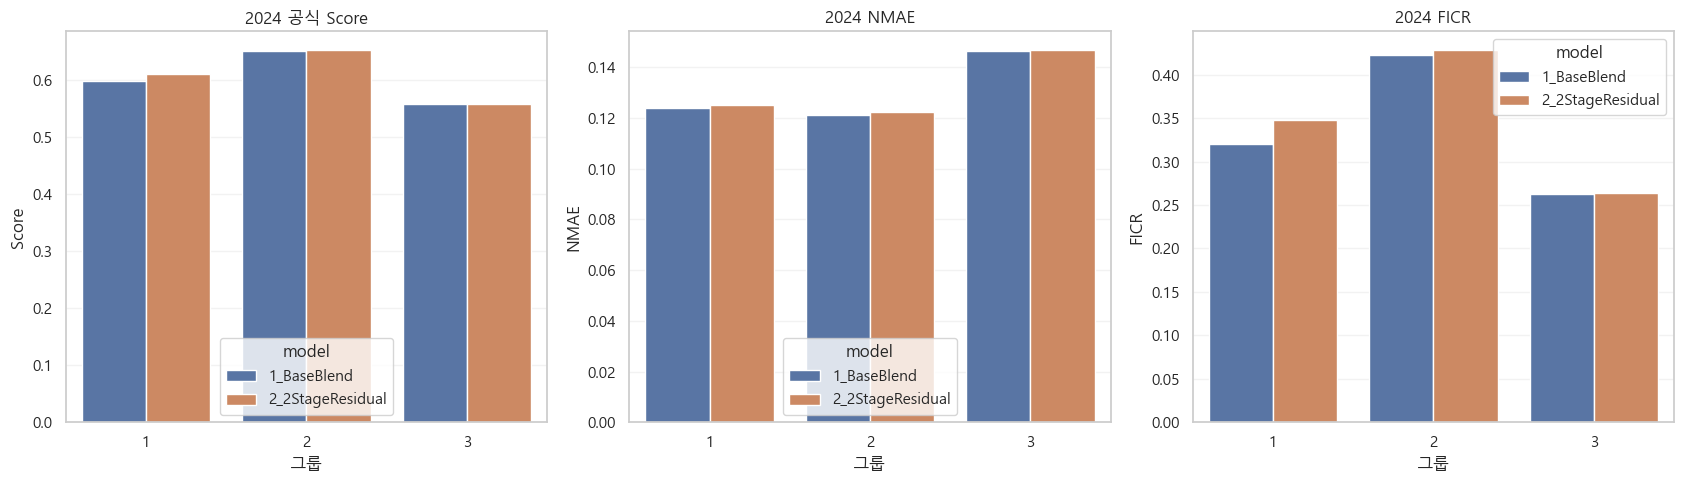

In [5]:
result_rows = []
for group_id in GROUPS:
    result = group_results[group_id]
    result_rows.append({
        "group": group_id,
        "base_Score": result["base_metrics"]["Score"],
        "2stage_Score": result["final_metrics"]["Score"],
        "Score_change": result["final_metrics"]["Score"] - result["base_metrics"]["Score"],
        "base_NMAE": result["base_metrics"]["NMAE"],
        "2stage_NMAE": result["final_metrics"]["NMAE"],
        "base_FICR": result["base_metrics"]["FICR"],
        "2stage_FICR": result["final_metrics"]["FICR"],
        "base_lgb_weight": result["base_lgb_weight"],
        "residual_lgb_weight": result["residual_lgb_weight"],
        "beta": result["beta"],
    })

result_df = pd.DataFrame(result_rows)
base_macro_nmae = float(result_df["base_NMAE"].mean())
base_macro_ficr = float(result_df["base_FICR"].mean())
base_macro_score = 0.5 * (1.0 - base_macro_nmae) + 0.5 * base_macro_ficr
final_macro_nmae = float(result_df["2stage_NMAE"].mean())
final_macro_ficr = float(result_df["2stage_FICR"].mean())
final_macro_score = 0.5 * (1.0 - final_macro_nmae) + 0.5 * final_macro_ficr

print(f"2024 기본회귀 Macro Score: {base_macro_score:.6f}")
print(f"2024 2-Stage Macro Score: {final_macro_score:.6f}")
print(f"Score 변화: {final_macro_score - base_macro_score:+.6f}")
display(result_df)

plot_df = comparison_df
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.barplot(data=plot_df, x="group", y="Score", hue="model", ax=axes[0])
sns.barplot(data=plot_df, x="group", y="NMAE", hue="model", ax=axes[1])
sns.barplot(data=plot_df, x="group", y="FICR", hue="model", ax=axes[2])
axes[0].set_title("2024 공식 Score")
axes[1].set_title("2024 NMAE")
axes[2].set_title("2024 FICR")
for ax in axes:
    ax.set_xlabel("그룹")
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 6. 2022~2024 전체 OOF 잔차학습과 2025 예측

2024년 검증에서 선택한 혼합비율·beta·트리 수를 고정합니다. 전체 Train을 4-fold로 나눠 기본 OOF를 다시 만들고, 2022~2024년 전체 잔차로 2단계를 학습합니다. 기본모델도 전체 Train으로 다시 학습합니다.


In [6]:
final_models = {}
prediction_frames = []

for group_id, group_info in GROUPS.items():
    print("\n" + "=" * 88)
    print(f"Group {group_id}: 2022~2024 전체 OOF 및 전체학습")
    cache = data_cache[group_id]
    config = group_results[group_id]
    x_all, y_all, x_test = cache["x_all"], cache["y_all"], cache["x_test"]
    folds = list(KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED).split(x_all))
    lgb_oof = np.zeros(len(x_all))
    cat_oof = np.zeros(len(x_all))

    for fold_id, (fit_idx, valid_idx) in enumerate(folds, 1):
        fold_lgb, fold_cat = fit_base_fixed(
            x_all.iloc[fit_idx], y_all[fit_idx],
            config["iterations"]["base_lgb"], config["iterations"]["base_cat"],
        )
        lgb_oof[valid_idx] = fold_lgb.predict(x_all.iloc[valid_idx])
        cat_oof[valid_idx] = fold_cat.predict(x_all.iloc[valid_idx])
        print(f"  전체 기본 OOF {fold_id}/{N_SPLITS} 완료")

    base_oof = np.maximum(
        0.0,
        config["base_lgb_weight"] * lgb_oof
        + (1.0 - config["base_lgb_weight"]) * cat_oof,
    )
    residual_target = y_all - base_oof
    x_stage2_all = make_stage2_features(x_all, lgb_oof, cat_oof, base_oof)
    residual_lgb, residual_cat = fit_residual_fixed(
        x_stage2_all, residual_target,
        config["iterations"]["res_lgb"], config["iterations"]["res_cat"],
    )

    base_lgb, base_cat = fit_base_fixed(
        x_all, y_all,
        config["iterations"]["base_lgb"], config["iterations"]["base_cat"],
    )
    test_lgb = base_lgb.predict(x_test)
    test_cat = base_cat.predict(x_test)
    base_test = np.maximum(
        0.0,
        config["base_lgb_weight"] * test_lgb
        + (1.0 - config["base_lgb_weight"]) * test_cat,
    )
    x_stage2_test = make_stage2_features(x_test, test_lgb, test_cat, base_test)
    residual_test = (
        config["residual_lgb_weight"] * residual_lgb.predict(x_stage2_test)
        + (1.0 - config["residual_lgb_weight"]) * residual_cat.predict(x_stage2_test)
    )
    final_ratio = np.maximum(0.0, base_test + config["beta"] * residual_test)

    prediction_frames.append(pd.DataFrame({
        TIME_COL: cache["test"][TIME_COL],
        group_info["target"]: final_ratio * group_info["capacity"],
    }))
    final_models[group_id] = {
        "base_lightgbm": base_lgb, "base_catboost": base_cat,
        "residual_lightgbm": residual_lgb, "residual_catboost": residual_cat,
        "feature_cols": cache["feature_cols"], "capacity": group_info["capacity"],
        "target": group_info["target"], "seed": RANDOM_SEED,
        "configuration": config,
    }
    print(f"  완료: beta={config['beta']:.2f}, 평균예측={np.mean(final_ratio * group_info['capacity']):.1f} kWh")



Group 1: 2022~2024 전체 OOF 및 전체학습
  전체 기본 OOF 1/4 완료
  전체 기본 OOF 2/4 완료
  전체 기본 OOF 3/4 완료
  전체 기본 OOF 4/4 완료
  완료: beta=1.00, 평균예측=7367.5 kWh

Group 2: 2022~2024 전체 OOF 및 전체학습
  전체 기본 OOF 1/4 완료
  전체 기본 OOF 2/4 완료
  전체 기본 OOF 3/4 완료
  전체 기본 OOF 4/4 완료
  완료: beta=0.50, 평균예측=7855.0 kWh

Group 3: 2022~2024 전체 OOF 및 전체학습
  전체 기본 OOF 1/4 완료
  전체 기본 OOF 2/4 완료
  전체 기본 OOF 3/4 완료
  전체 기본 OOF 4/4 완료
  완료: beta=0.30, 평균예측=6220.8 kWh


## 7. 제출 CSV·통합 모델·요약 저장

결과 폴더에는 제출 CSV, 통합 모델, 요약 JSON 세 파일만 저장합니다.


In [7]:
sample = pd.read_csv(DATA_DIR / "sample_submission.csv", encoding="utf-8-sig", parse_dates=[TIME_COL])
targets = [GROUPS[g]["target"] for g in GROUPS]
pred_table = prediction_frames[0]
for frame in prediction_frames[1:]:
    pred_table = pred_table.merge(frame, on=TIME_COL, how="inner", validate="one_to_one")
submission = sample.drop(columns=targets).merge(
    pred_table, on=TIME_COL, how="left", validate="one_to_one"
)[sample.columns]

if len(submission) != len(sample) or submission[targets].isna().any().any():
    raise ValueError("제출 행 수 또는 시간 매칭이 sample_submission과 다릅니다.")
if not np.isfinite(submission[targets].to_numpy(dtype=float)).all():
    raise ValueError("제출값에 무한대 또는 비수치 값이 있습니다.")
if (submission[targets] < 0).any().any():
    raise ValueError("음수 차단 이후에도 음수 예측이 남았습니다.")

submission_path = OUTPUT_DIR / "submission_2stage_residual.csv"
models_path = OUTPUT_DIR / "models_2stage_residual.pkl"
summary_path = OUTPUT_DIR / "summary_2stage_residual.json"
submission.to_csv(submission_path, index=False, encoding="utf-8-sig", date_format="%Y-%m-%d %H:%M:%S")
with models_path.open("wb") as file:
    pickle.dump(final_models, file, protocol=pickle.HIGHEST_PROTOCOL)

summary = {
    "model": "Base LightGBM+CatBoost -> Residual LightGBM+CatBoost",
    "seed": RANDOM_SEED,
    "validation": "2022~2023 train -> 2024 holdout",
    "internal_oof": "4-fold KFold for residual training only",
    "final_training": "2022~2024 full base OOF + full residual + full base refit",
    "validation_metrics": {
        "base_macro_Score": base_macro_score,
        "base_macro_NMAE": base_macro_nmae,
        "base_macro_FICR": base_macro_ficr,
        "2stage_macro_Score": final_macro_score,
        "2stage_macro_NMAE": final_macro_nmae,
        "2stage_macro_FICR": final_macro_ficr,
    },
    "groups": {str(g): group_results[g] for g in GROUPS},
    "runtime_minutes": (time.perf_counter() - run_started) / 60,
    "files": {"submission": str(submission_path), "models": str(models_path)},
}
with summary_path.open("w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

print("\n저장 완료")
print("제출:", submission_path)
print("모델:", models_path)
print("요약:", summary_path)
print(f"2024 2-Stage 공식 검증 Score: {final_macro_score:.6f}")
print(f"전체 실행시간: {(time.perf_counter() - run_started) / 60:.1f}분")
display(submission.head())



저장 완료
제출: C:\jupyter project\wind_2stage_residual_output\submission_2stage_residual.csv
모델: C:\jupyter project\wind_2stage_residual_output\models_2stage_residual.pkl
요약: C:\jupyter project\wind_2stage_residual_output\summary_2stage_residual.json
2024 2-Stage 공식 검증 Score: 0.607585
전체 실행시간: 483.3분


,forecast_id,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,forecast_0001,2025-01-01 01:00:00,19214.006216,18896.150718,16433.630003
1,forecast_0002,2025-01-01 02:00:00,19303.697021,19360.613123,16695.207589
2,forecast_0003,2025-01-01 03:00:00,17692.279732,17858.070435,16785.947301
3,forecast_0004,2025-01-01 04:00:00,17546.438737,17936.022969,15495.124496
4,forecast_0005,2025-01-01 05:00:00,16727.321560,17660.014058,14422.007302


## 8. 오류와 해석 시 주의사항

1. 내부 KFold는 2024년 검증을 대신하지 않습니다. 잔차 학습용 OOF를 만들기 위한 과정입니다.
2. 2024년은 최종 설정을 고르는 데 사용하므로 같은 2024년 점수를 반복해서 과도하게 최적화하지 않습니다.
3. `beta=0`도 후보에 있으므로 잔차보정이 해로우면 기본모델로 자동 복귀합니다.
4. 최종 단계는 전체 기본 OOF를 다시 생성하므로 단순 전체 재학습보다 오래 걸리는 것이 정상입니다.
5. 설비용량 상한을 적용하지 않았으므로 제출 전에 용량 초과 예측 분포도 확인할 수 있습니다.
